In [ ]:
#Names: Trevor Henderson, Nick Garcia  (Monday, Wednesday)
#dataset: https://www.kaggle.com/datasets/uciml/mushroom-classification

# Import the tools needed to load data, train the Naive Bayes model,
# and measure how accurate the predictions are
import pandas as pd
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Load the mushroom dataset so we can explore its features
# Each row represents one mushroom with labeled characteristics

df = pd.read_csv("mushrooms.csv")

print("=== STEP 2: Original Dataset ===")
print(df.head())
print()
print("Dataset shape:", df.shape)
print()

=== STEP 2: Original Dataset ===
  class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   
3     p         x           y         w       t    p               f   
4     e         x           s         g       f    n               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   
3            c         n          n  ...                        s   
4            w         b          k  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w

In [ ]:
# Convert category text values into numbers so the model can process them
# Each column is encoded separately to preserve its category meanings

encoders = {}

for column in df.columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column])
    encoders[column] = encoder

print("=== STEP 3: After Label Encoding ===")
print(df.head())
print()

=== STEP 3: After Label Encoding ===
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0          1           5  ...                         2   
4             1          0           4  ...                         2   

   stalk-color-above-ring  stalk-color-below-ring

In [ ]:
# Remove columns that are not useful for prediction
# This helps prevent errors and keeps the model focused on relevant data

X = df.drop("class", axis=1)
y = df["class"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = CategoricalNB()
model.fit(X_train, y_train)

print("=== STEP 5: Model trained! ===")
print()

=== STEP 5: Model trained! ===



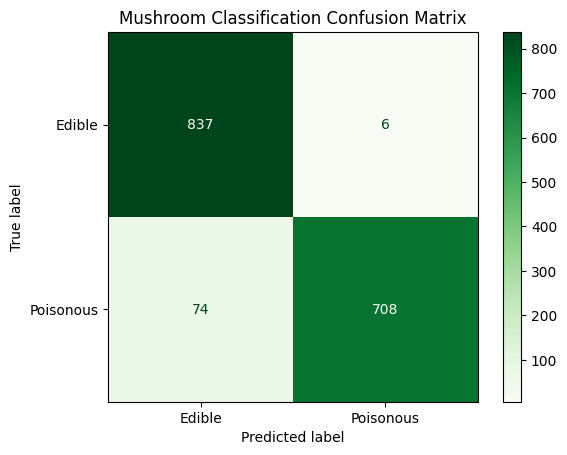

In [ ]:
# Visual confusion matrix for mushroom predictions
# Shows where the model predicted edible vs poisonous correctly

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    display_labels=["Edible", "Poisonous"],
    cmap="Greens"
)

plt.title("Mushroom Classification Confusion Matrix")
plt.show()

In [ ]:
# Show precision, recall, and F1-score for mushroom predictions
# These metrics evaluate how well the model classifies edible vs poisonous mushrooms

from sklearn.metrics import classification_report

print("Classification Report (Mushroom Model):")
print(classification_report(
    y_test,
    predictions,
    target_names=["Edible", "Poisonous"]
))

Classification Report (Mushroom Model):
              precision    recall  f1-score   support

      Edible       0.92      0.99      0.95       843
   Poisonous       0.99      0.91      0.95       782

    accuracy                           0.95      1625
   macro avg       0.96      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625



In [ ]:

# Test the model using a new mushroom example
# The probability scores show how confident the model is in its prediction


new_mushrooms = [
    {
        "cap-shape": "x",
        "cap-surface": "s",
        "cap-color": "n",
        "bruises": "t",
        "odor": "p",
        "gill-attachment": "f",
        "gill-spacing": "c",
        "gill-size": "n",
        "gill-color": "k",
        "stalk-shape": "e",
        "stalk-root": "e",
        "stalk-surface-above-ring": "s",
        "stalk-surface-below-ring": "s",
        "stalk-color-above-ring": "w",
        "stalk-color-below-ring": "w",
        "veil-type": "p",
        "veil-color": "w",
        "ring-number": "o",
        "ring-type": "p",
        "spore-print-color": "k",
        "population": "s",
        "habitat": "u"
    },
    {
        "cap-shape": "b",
        "cap-surface": "s",
        "cap-color": "y",
        "bruises": "t",
        "odor": "a",
        "gill-attachment": "f",
        "gill-spacing": "c",
        "gill-size": "b",
        "gill-color": "k",
        "stalk-shape": "e",
        "stalk-root": "c",
        "stalk-surface-above-ring": "s",
        "stalk-surface-below-ring": "s",
        "stalk-color-above-ring": "w",
        "stalk-color-below-ring": "w",
        "veil-type": "p",
        "veil-color": "w",
        "ring-number": "o",
        "ring-type": "p",
        "spore-print-color": "n",
        "population": "v",
        "habitat": "g"
    }
]

print("=== STEP 7: Predictions for new mushrooms ===")
print()

for mushroom in new_mushrooms:
    encoded_row = []

    for column in X.columns:
        encoded_value = encoders[column].transform([mushroom[column]])[0]
        encoded_row.append(encoded_value)

    # make dataframe so feature names match training data
    encoded_df = pd.DataFrame([encoded_row], columns=X.columns)

    prediction = model.predict(encoded_df)[0]
    probability = model.predict_proba(encoded_df)[0]

    result = encoders["class"].inverse_transform([prediction])[0]

    print("Mushroom sample:", mushroom)
    print(f"  --> Predicted class: {result}")
    print(f"  --> Probability edible   : {probability[0] * 100:.1f}%")
    print(f"  --> Probability poisonous: {probability[1] * 100:.1f}%")
    print()

=== STEP 7: Predictions for new mushrooms ===

Mushroom sample: {'cap-shape': 'x', 'cap-surface': 's', 'cap-color': 'n', 'bruises': 't', 'odor': 'p', 'gill-attachment': 'f', 'gill-spacing': 'c', 'gill-size': 'n', 'gill-color': 'k', 'stalk-shape': 'e', 'stalk-root': 'e', 'stalk-surface-above-ring': 's', 'stalk-surface-below-ring': 's', 'stalk-color-above-ring': 'w', 'stalk-color-below-ring': 'w', 'veil-type': 'p', 'veil-color': 'w', 'ring-number': 'o', 'ring-type': 'p', 'spore-print-color': 'k', 'population': 's', 'habitat': 'u'}
  --> Predicted class: e
  --> Probability edible   : 73.8%
  --> Probability poisonous: 26.2%

Mushroom sample: {'cap-shape': 'b', 'cap-surface': 's', 'cap-color': 'y', 'bruises': 't', 'odor': 'a', 'gill-attachment': 'f', 'gill-spacing': 'c', 'gill-size': 'b', 'gill-color': 'k', 'stalk-shape': 'e', 'stalk-root': 'c', 'stalk-surface-above-ring': 's', 'stalk-surface-below-ring': 's', 'stalk-color-above-ring': 'w', 'stalk-color-below-ring': 'w', 'veil-type': 'p',

This code builds a machine learning model that learns how to classify mushrooms as edible or poisonous based on their physical features. It first converts category data into numbers so the model can understand it, then trains on part of the dataset and tests how accurate its predictions are on new data. The results show how reliable the model is using accuracy, confusion matrix results, and other evaluation scores. In the real world, models like this could be used to help quickly sort items into categories, support safety checks, or assist decision-making in areas where identifying risk correctly is important.